In [29]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, uniform, norm
from scipy.stats import geom

# Exercise 1


## 1 

In [30]:
def linear_conguence_operator(a,c,M,x):
    xi =(a*x+c) % M
    random_number = xi/M
    return random_number,xi

In [31]:
def linear_congruence_RNG(a,c,M,x,n): 
    numbers = []
    for i in range(n): 
        random_number, x = linear_conguence_operator(a,c,M,x)
        numbers.append(random_number)
    return numbers

In [32]:
def chi_square_test(n_observed, n_expected,m):
    n_observed = np.asarray(n_observed, dtype=float)
    n_expected = np.asarray(n_expected, dtype=float)
    n = len(n_observed)
    df = n-1-m
    T = np.sum(((n_observed-n_expected)**2)/n_expected)
    return chi2.sf(T,df)


### a)

(array([1250.,  625., 1250.,  625., 1250.,  625., 1250.,  625., 1250.,
        1250.]),
 array([0.     , 0.09375, 0.1875 , 0.28125, 0.375  , 0.46875, 0.5625 ,
        0.65625, 0.75   , 0.84375, 0.9375 ]),
 <BarContainer object of 10 artists>)

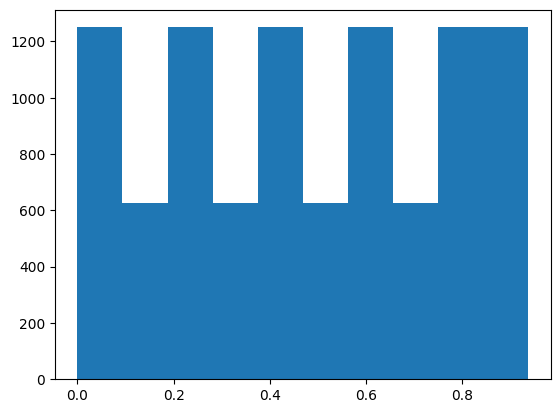

In [33]:
# Generating random numbers (10000) and histogram
num = linear_congruence_RNG(5,1,16,3,10000)
plt.hist(num,10)

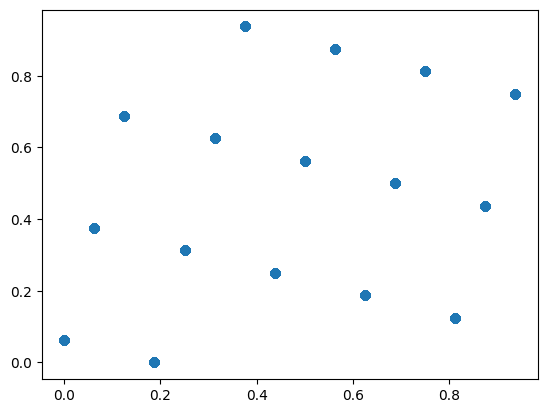

In [34]:
plt.scatter(num[:-1],num[1:])

In [35]:
# chi squared
bins = 10
observed, _ = np.histogram(num, bins=bins)
expected = np.ones(bins) * (10000 / bins)
chi_square_test(observed,expected, 0)

5.132863848608182e-196

In [36]:
# Kologmigigi
def empirical_cdf(x,num): 
    num = np.array(num)
    return np.sum(num <= x)/len(num)

def Kolmogorov_smirnov(num, n):
    x = np.linspace(0,1,n) # n controls how close we are to treating it like a continous function
    val = []
    for i in x:
        val.append(abs(uniform.cdf(i)-empirical_cdf(i,num)))

    return np.max( val)


In [37]:
# Need to standardize to compare
(np.sqrt(10000)+0.12+0.11/(np.sqrt(10000)))*Kolmogorov_smirnov(num, 100)

6.25756875

In [38]:
## Wald-Wolfowitz
def Wald_wolf(num):
    median = np.median(num)
    n1 = int(np.sum(np.array(num)>= median))
    n2 = int(np.sum(np.array(num) < median))
    mu = 2*(n1*n2/(n1+n2))+1
    sd = 2*(n1*n2*(2*n1*n2-n1-n2)/((n1+n2)**2*(n1+n2-1)))

    label = ["A" if i >= median else "B" for i in num]
    T = 1
    for i in range(1, len(label)):
        if label[i] != label[i - 1]:
            T += 1
    
    T_std = abs((T-mu)/np.sqrt(sd))
    return 2*(norm.sf(T_std))


In [39]:
Wald_wolf(num)

5.924971670843113e-138

In [40]:
# Run test 2 - UP/down KNUTH

def Knuth_up_down(num):
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ]).flatten()

    runs = []
    current_len = 1

    for i in range(1, len(num)):
        if num[i] > num[i - 1]:
            current_len += 1
        else:
            runs.append(current_len)
            current_len = 1

    R = [0] * 6 
    for r in runs:
        if r >= 6:
            R[5] += 1
        else:
            R[r - 1] += 1
    R = np.array(R)
    z = 1/(len(num)-6)*((R-len(num)*B).T)@A@(R-len(num)*B)
    return chi2.sf(z,6)


In [41]:
def correlation_coef(num,h):
    n= len(num)
    num = np.array(num)
    c = 1/(n-h)*np.sum(num[:-h]*num[h:])
    c_std = abs((c-0.25)/np.sqrt(7/(144*n)))
    return 2*(norm.sf(c_std))


In [42]:
correlation_coef(num,4) # Det er endnu mere rejectable når h bliver større

4.2893305640587635e-77

## Nu med gode tal

(array([ 985.,  902.,  977., 1060., 1017., 1029., 1027.,  949., 1012.,
        1042.]),
 array([7.55286310e-05, 1.00057015e-01, 2.00038501e-01, 3.00019986e-01,
        4.00001472e-01, 4.99982958e-01, 5.99964444e-01, 6.99945930e-01,
        7.99927416e-01, 8.99908902e-01, 9.99890388e-01]),
 <BarContainer object of 10 artists>)

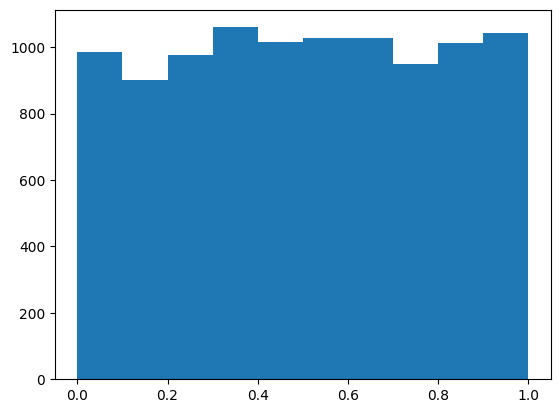

In [43]:
a = 1203515245
c =12345
M = 2**32
# Generating random numbers (10000) and histogram
num = linear_congruence_RNG(a,c,M,3,10000)
plt.hist(num,10)

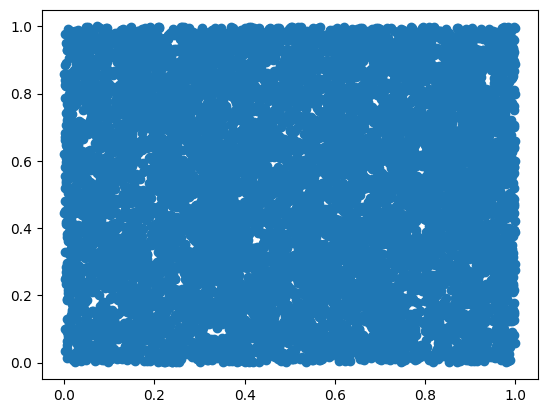

In [44]:
plt.scatter(num[:-1],num[1:])

In [45]:
# Test
ran = np.random.rand(10000)

bins = 10
observed, _ = np.histogram(ran, bins=bins)

expected = np.ones(bins) * len(ran) / bins

print("Chi_square", chi_square_test(observed, expected, 0))
print("Kolmogorov_smirnov", (np.sqrt(10000)+0.12+0.11/(np.sqrt(10000)))*Kolmogorov_smirnov(num, 100))
print("Wald", Wald_wolf(num))
print("Knut", Knuth_up_down(num))
print("corr, h=1", correlation_coef(num,1))


Chi_square 0.9308382959045326
Kolmogorov_smirnov 1.5445955154545516
Wald 0.3680962993145487
Knut 0.4927805129254733
corr, h=1 0.008240736781768804


## 2

In [46]:
ran = np.random.rand(10000)

bins = 10
observed, _ = np.histogram(ran, bins=bins)

expected = np.ones(bins) * len(ran) / bins

print("Chi_square", chi_square_test(observed, expected, 0))
print("Kolmogorov_smirnov", (np.sqrt(10000)+0.12+0.11/(np.sqrt(10000)))*Kolmogorov_smirnov(ran, 100))
print("Wald", Wald_wolf(ran))
print("Knut", Knuth_up_down(ran))
print("corr, h=1", correlation_coef(ran,1))

Chi_square 0.8649759302298503
Kolmogorov_smirnov 0.5766570830303146
Wald 0.2713081546840427
Knut 0.4157955336960027
corr, h=1 0.6958514423831805


# Exercise 2

In [47]:
from scipy.stats import kstest, chisquare, expon
from statsmodels.sandbox.stats.runs import runstest_1samp

## Part 1

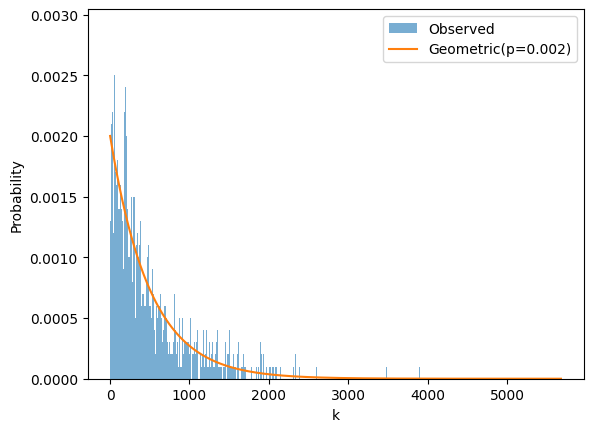

In [48]:
p = 0.002

# Simulate 10_000 random from a uniform distribution
np.random.seed(42)
U = np.random.rand(10_000)

# Turn this into the geometric distribution using what is given in slides: 
X = np.floor(np.log(U)/np.log(1-p))+1
# Histogram of observed data
plt.hist(X,
         bins=np.arange(1, X.max() + 2) - 0.5,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical geometric PMF
x = np.arange(1, X.max() + 1)
plt.plot(x, geom.pmf(x, p), '-', label=f'Geometric(p={p})')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()



In [49]:
max_x = X.max()
x_vals = np.arange(1, max_x + 1)
theoretical_pdf = p * (1 - p) ** (x_vals - 1)
f_expected = theoretical_pdf*len(X)
f_obs = np.bincount(X.astype(int))[1:]
#chisquare(f_obs,f_expected,0) # Der er noget med noget afrudning som ikke virker, så går videre

In [50]:
median = np.median(X)
binary = (X > median).astype(int)
stat, p_value = runstest_1samp(X,cutoff='median')
p_value

0.31704979367248654

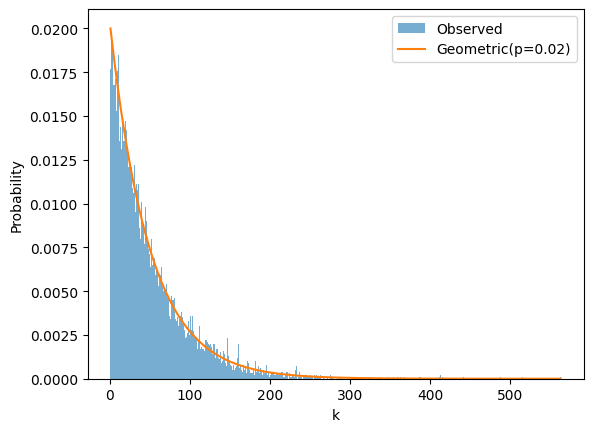

run:  0.31709083333751975


In [51]:
p = 0.02

# Simulate 10_000 random from a uniform distribution
np.random.seed(42)
U = np.random.rand(10_000)

# Turn this into the geometric distribution using what is given in slides: 
X = np.floor(np.log(U)/np.log(1-p))+1
# Histogram of observed data
plt.hist(X,
         bins=np.arange(1, X.max() + 2) - 0.5,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical geometric PMF
x = np.arange(1, X.max() + 1)
plt.plot(x, geom.pmf(x, p), '-', label=f'Geometric(p={p})')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()

stat, p_value = runstest_1samp(X,cutoff='median')
print("run: ", p_value)

# 

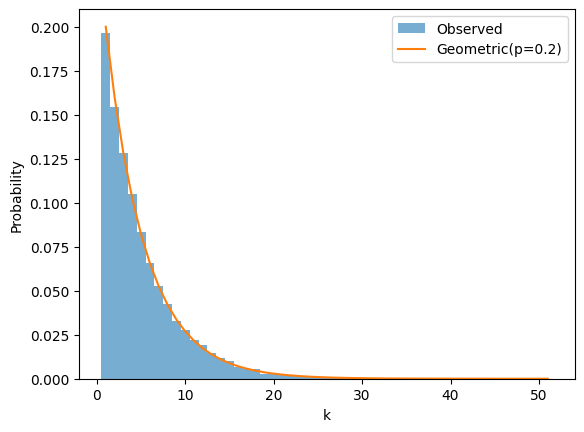

run:  0.6141680967242491


In [52]:
p = 0.2

# Simulate 10_000 random from a uniform distribution
np.random.seed(42)
U = np.random.rand(10_000)

# Turn this into the geometric distribution using what is given in slides: 
X = np.floor(np.log(U)/np.log(1-p))+1
# Histogram of observed data
plt.hist(X,
         bins=np.arange(1, X.max() + 2) - 0.5,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical geometric PMF
x = np.arange(1, X.max() + 1)
plt.plot(x, geom.pmf(x, p), '-', label=f'Geometric(p={p})')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()


stat, p_value = runstest_1samp(X,cutoff='median')
print("run: ", p_value)


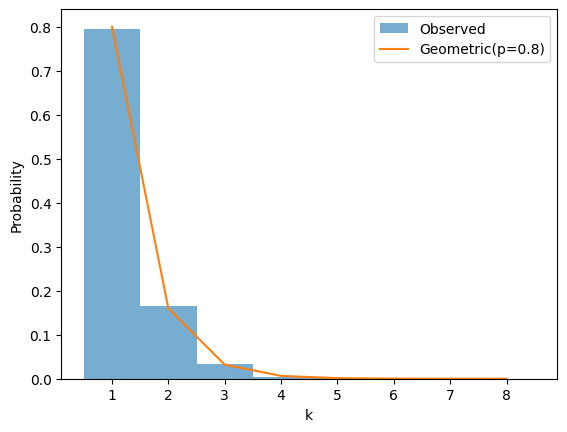

run:  nan


c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\sandbox\stats\runs.py:102: RuntimeWarning: invalid value encountered in scalar divide
  z /= rstd


In [53]:
p = 0.8

# Simulate 10_000 random from a uniform distribution
np.random.seed(42)
U = np.random.rand(10_000)

# Turn this into the geometric distribution using what is given in slides: 
X = np.floor(np.log(U)/np.log(1-p))+1
# Histogram of observed data
plt.hist(X,
         bins=np.arange(1, X.max() + 2) - 0.5,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical geometric PMF
x = np.arange(1, X.max() + 1)
plt.plot(x, geom.pmf(x, p), '-', label=f'Geometric(p={p})')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()


stat, p_value = runstest_1samp(X,cutoff='median')
print("run: ", p_value)

They are worse for very smaller 

## Part 2

In [54]:
x = np.array([1,2,3,4,5,6])
p = np.array([7/48,5/48,1/8,1/16, 1/4, 5/16])


In [55]:
# Direct method
def direct_method(U,p):
    intervals = np.cumsum(p)
    index = intervals.searchsorted(U)
    X = x[index]
    return X

direct_method(U,p)

array([3, 6, 6, ..., 6, 4, 2])

In [56]:
# simple rejection
def simple_rejection(n,x,p,eps):
    X = []
    k = len(x)
    c = np.max(p)+eps
    while len(X)<10_000:
        I = np.floor(k*np.random.rand())+1
        if np.random.rand() <=p[int(I)-1]/c:
            X.append(int(I))
    return np.array(X)
np.random.seed(42)
X = simple_rejection(10000,x,p,0.01)
X


array([5, 1, 5, ..., 5, 1, 6])

In [57]:
def alias_method(x,p,n,eps):
    k = len(x)
    L = np.arange(1,k+1,1)
    F = k*p
    G = [idx for idx in range(k) if F[idx] >= 1]
    S = [idx for idx in range(k) if F[idx] < 1]
    while len(S)>0:
        i = G[0]
        j = S[0]
        L[j] = i
        F[i]= F[i]-(1-F[j])
        if F[i]<1-eps:
            S.append(i)
            G.pop(0)
        S.pop(0)
    X = []
    while len(X)<10000: 
        I = np.floor(k*np.random.rand())+1
        if np.random.rand() <=F[int(I-1)]:
            X.append(int(I))
        else: 
            X.append(L[int(I-1)])
    return np.array(X)


In [58]:
np.random.seed(42)
alias_method(x,p,10000,0.001)

array([4, 5, 1, ..., 6, 1, 3])

## 3

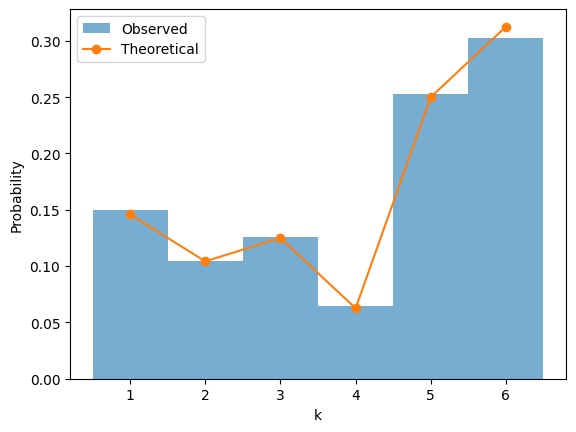

run:  0.16686748319150968


In [59]:
# Histogram of observed data
X = direct_method(U,p)
plt.hist(X,
         bins=np.arange(1, X.max() + 2) - 0.5,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

plt.plot(x, p, 'o-', label='Theoretical')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()


stat, p_value = runstest_1samp(X,cutoff='median')
print("run: ", p_value)

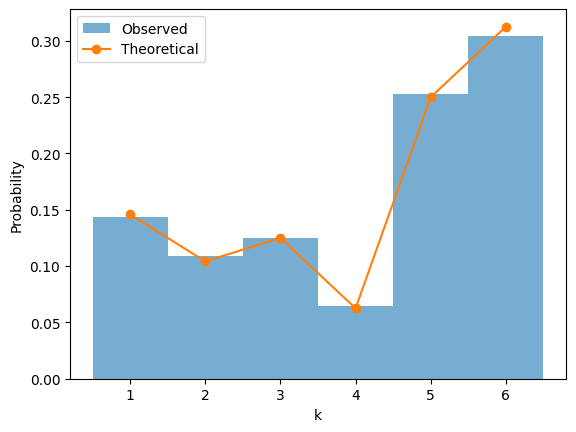

run:  0.04676725086510697


In [60]:
# Histogram of observed data
np.random.seed(42)
X = simple_rejection(10000,x,p,0.01)
plt.hist(X,
         bins=np.arange(1, X.max() + 2) - 0.5,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

plt.plot(x, p, 'o-', label='Theoretical')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()


stat, p_value = runstest_1samp(X,cutoff='median')
print("run: ", p_value)

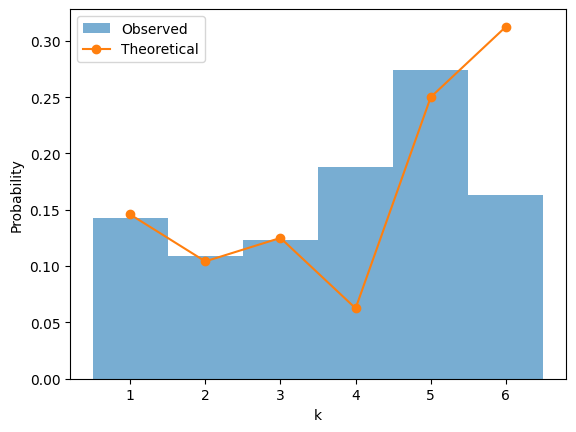

run:  0.8728604587309523


In [61]:
# Histogram of observed data
np.random.seed(42)
X = alias_method(x,p,10000,0.001)
plt.hist(X,
         bins=np.arange(1, X.max() + 2) - 0.5,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

plt.plot(x, p, 'o-', label='Theoretical')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()


stat, p_value = runstest_1samp(X,cutoff='median')
print("run: ", p_value)

# Exercise 3

In [62]:
from scipy.stats import pareto, t, chi2

## Exponential

In [63]:
# Exponential
np.random.seed(42)
U = np.random.rand(10_000)
def exp_distribution(U,rate): 
    return -np.log(U)/rate

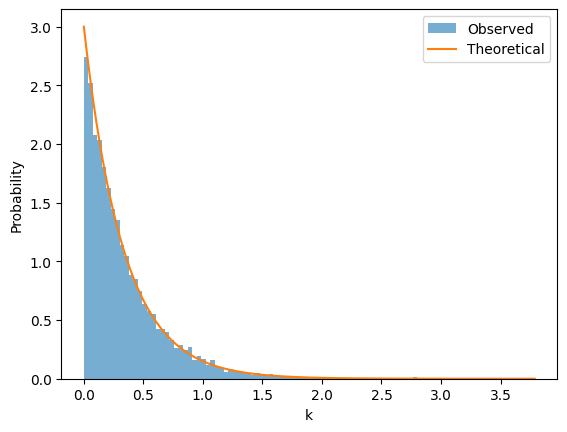

run:  0.21495245879429403


In [64]:
# plot: 


# Histogram of observed data
np.random.seed(42)
rate = 3
X = exp_distribution(U,rate)
plt.hist(X,
         bins=100,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical
x = np.linspace(np.min(X),np.max(X),100000)
theoretical_pdf_exp = rate*np.exp(-rate*x)

plt.plot(x, theoretical_pdf_exp, '-', label='Theoretical')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()


stat, p_value = runstest_1samp(X,cutoff='median')
print("run: ", p_value)

In [65]:
bin_edges = np.array([
    0.0, 0.1, 0.2, 0.3, 0.5,
    0.8, 1.2, np.inf
])

# Observed frequencies
observed, _ = np.histogram(X, bins=bin_edges)

# Expected frequencies
cdf_vals = expon(scale=1/rate).cdf(bin_edges)
expected = len(X) * np.diff(cdf_vals)

# Chi-square
chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

print("pvalue:", p_value)

pvalue: 0.24969517495588162


## Normal distribution

In [66]:
# Normal distribution through Box-Muller
def normal_distribution(n, mu,std): 
    U1 = np.random.rand(n)
    U2 = np.random.rand(n)
    return mu+ std*np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)

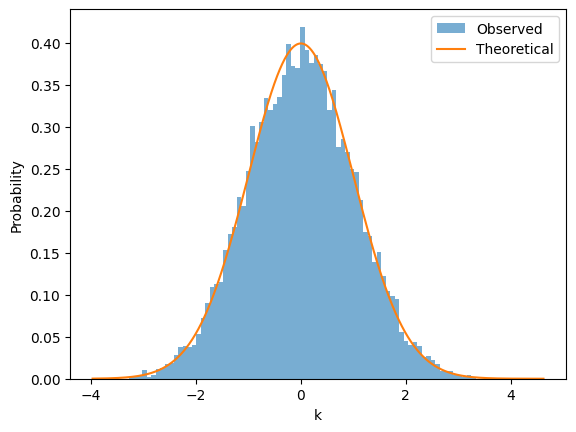

run:  0.6170574712145741


In [67]:
# plot: 


# Histogram of observed data
np.random.seed(42)
mu =0
std = 1
X = normal_distribution(10000,mu,std)
plt.hist(X,
         bins=100,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical

x = np.linspace(np.min(X),np.max(X),100000)
theoretical_pdf_exp = (1 / (std * np.sqrt(2 * np.pi))) * \
           np.exp(-0.5 * ((x - mu) / std) ** 2)

plt.plot(x, theoretical_pdf_exp, '-', label='Theoretical')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()


stat, p_value = runstest_1samp(X,cutoff='median')
print("run: ", p_value)

In [68]:
bin_edges = np.array([
    -np.inf,-4,-2,-1,0,1,2,4, np.inf
])

# Observed frequencies
observed, _ = np.histogram(X, bins=bin_edges)

# Expected frequencies
cdf_vals = norm(loc=mu, scale=std).cdf(bin_edges)
expected = len(X) * np.diff(cdf_vals)

# Chi-square
chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

print("pvalue:", p_value)

pvalue: 0.3366931861886777


## Pareto

In [69]:
beta = 1
k = [2.05, 2.5,3,4]
n = 10000

def pareto_distrib(k, beta, n):
    U = np.random.rand(n)
    return beta*(U**(-1/k))

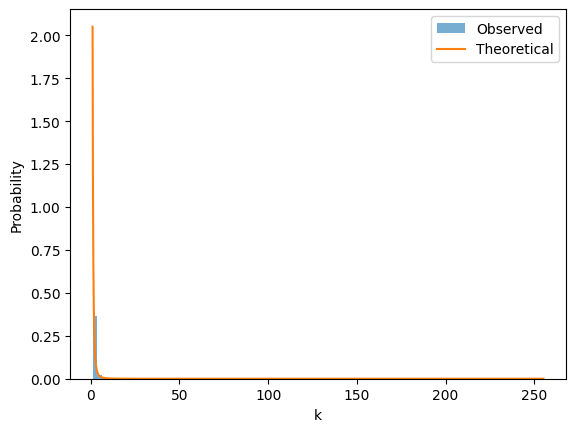

run:  0.21495245879429403


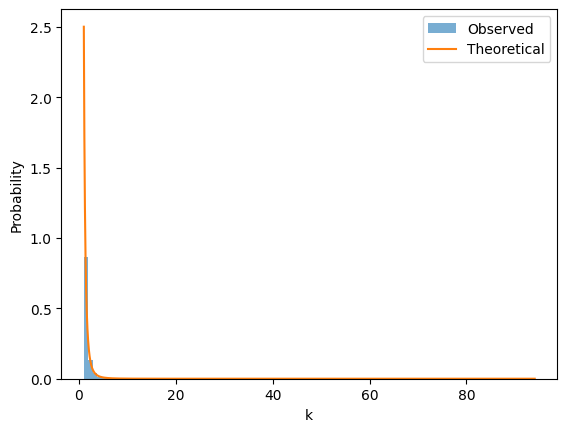

run:  0.21495245879429403


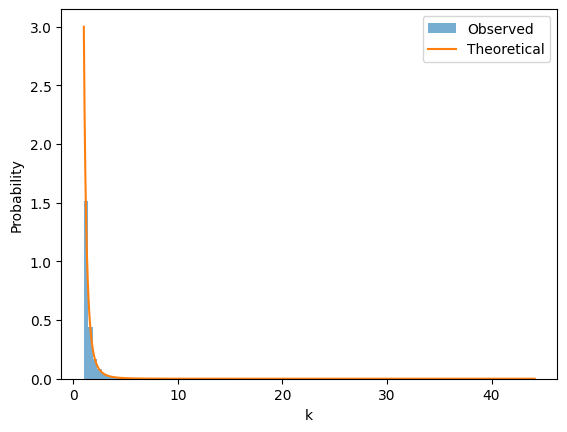

run:  0.21495245879429403


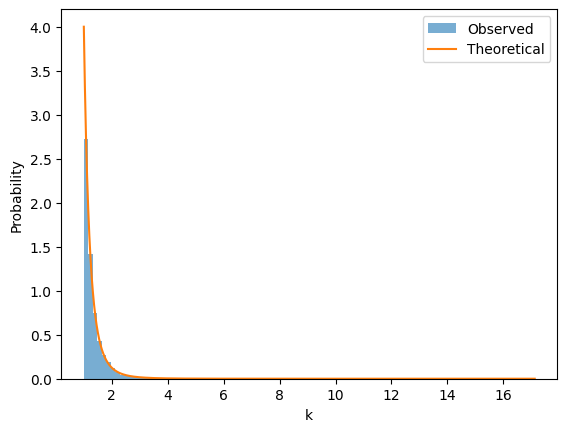

run:  0.21495245879429403


In [70]:
# plot: 


# Histogram of observed data
for i in range(len(k)):
    np.random.seed(42)
    X = pareto_distrib(k[i],beta,n)
    plt.hist(X,
            bins=100,
            density=True,
            alpha=0.6,
            label='Observed')

    # Theoretical

    x = np.linspace(beta,np.max(X),100000)
    theoretical_pdf_pareto = k[i]*beta**k[i]/(x**(k[i]+1))

    plt.plot(x, theoretical_pdf_pareto, '-', label='Theoretical')

    plt.xlabel('k')
    plt.ylabel('Probability')
    plt.legend()
    plt.show()


    stat, p_value = runstest_1samp(X,cutoff='median')
    print("run: ", p_value)

In [71]:

bin_edges = np.array([
    0.01,0.1,0.2,0.4,0.8,1,2, np.inf
])

# Observed frequencies
observed, _ = np.histogram(X, bins=bin_edges)

# Expected frequencies
cdf_p = pareto(k[0],beta)
cdf_vals = cdf_p.cdf(bin_edges)
expected = len(X) * np.diff(cdf_vals)

# Chi-square
chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

print("pvalue:", p_value)

pvalue: nan


c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_stats_py.py:7335: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
c:\Users\Bruger\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_stats_py.py:7335: RuntimeWarning: invalid value encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp


In [72]:
for i in k: 
    np.random.seed(42)
    X = pareto_distrib(i,beta,10000)
    # Bin edges smallest possible value is beta and then tails to infinity. 
    bin_edges =  np.array([beta, 1.2, 1.5, 1.8, 2.2, 3.0, 5.0, np.inf])
    # Observed frequencies
    observed, _ = np.histogram(X, bins=bin_edges)

    # Expected frequencies
    theoretical_cdf = 1.0 - (beta / bin_edges) **i
    expected = len(X) * np.diff(theoretical_cdf)

    # Chi-square goodness-of-fit test
    chi2_stat, p_value = chisquare(
    f_obs=observed,
        f_exp=expected
    )
    print("Chi-square statistic:", chi2_stat)
    print("p-value:", p_value)
    print(" ")

Chi-square statistic: 7.702638950406866
p-value: 0.2607081406642081
 
Chi-square statistic: 7.145969659829467
p-value: 0.3075588291013098
 
Chi-square statistic: 10.302236393692752
p-value: 0.11248772684452248
 
Chi-square statistic: 6.125328213683867
p-value: 0.40929830242547166
 


## 2

In [73]:
# Sample mean and variance: 
beta = 1
k = [2.05, 2.5,3,4]
n = 10000

for i in k: 
    np.random.seed(42)
    X = pareto_distrib(i,beta,10000)
    print("k = ", i)
    print("Mean:",np.mean(X))
    print("Variance:",np.var(X))

    print("Theo. Mean:",beta*i/(i-1))
    print("Theo. var.",beta**2*i/((i-1)**2*(i-2)))


k =  2.05
Mean: 1.9998743451428789
Variance: 15.481377951704149
Theo. Mean: 1.9523809523809526
Theo. var. 37.18820861678019
k =  2.5
Mean: 1.6880528954783494
Variance: 3.0518634193315926
Theo. Mean: 1.6666666666666667
Theo. var. 2.2222222222222223
k =  3
Mean: 1.5122025604717688
Variance: 0.9831112827611536
Theo. Mean: 1.5
Theo. var. 0.75
k =  4
Mean: 1.3396596202371285
Variance: 0.25860852659874684
Theo. Mean: 1.3333333333333333
Theo. var. 0.2222222222222222


Mean is in general pretty close, and improves when k grows. The variance is quite different particularly for k close to 2, improves when moving away from 2. We see in the theoretical variance we have a division with k-2, thus maybe when k close 2, and we simulate the stability is not so great 


# Spørg TA om ovenfor er rigtigt

## 3

We use the normal formulas for finding the 95% confidence intervals. Se gruppe chat for formler


In [74]:
np.random.seed(42)
CI_mean_upper_lst = []
CI_mean_lower_lst = []
CI_std_upper_lst = []
CI_std_lower_lst = []
mean_lst= []
sd_lst=[]
Is_mean_within_CI = 0
Is_std_within_CI=0
for i in range(100):
    n = 10
    X = normal_distribution(n,0,1)
    mean = np.mean(X)
    sd = np.std(X)
    CI_mean_upper = mean+t.ppf(0.975, df=n-1)*sd/np.sqrt(n)
    CI_mean_lower = mean-t.ppf(0.975, df=n-1)*sd/np.sqrt(n)
    CI_mean_lower_lst.append(CI_mean_lower)
    CI_mean_upper_lst.append(CI_mean_upper)

    CI_std_lower = np.sqrt((n-1)*sd**2/(chi2.ppf(0.025, n-1)))
    CI_std_upper = np.sqrt((n-1)*sd**2/(chi2.ppf(0.975, n-1)))
    CI_std_lower_lst.append(CI_std_lower)
    CI_std_upper_lst.append(CI_std_upper)

    if (0 < CI_mean_upper) and (0 > CI_mean_lower):
        Is_mean_within_CI +=1
    if (1 < CI_std_lower) and (1 > CI_std_upper): # er kommet til at bytte rundt på ovre og nedre i navngivning
        Is_std_within_CI +=1

    mean_lst.append(mean)
    sd_lst.append(sd)


In [75]:
print("Mean:", np.mean(CI_mean_lower_lst), np.mean(CI_mean_upper_lst))
print("Std:", np.mean(CI_std_lower_lst), np.mean(CI_std_upper_lst))

Mean: -0.6526104922891715 0.6817939180930088
Std: 1.7027180829595876 0.6415331464745547


In [76]:
np.mean(mean_lst)

0.014591712901918706

In [77]:
np.mean(sd_lst)

0.9326843700058797

In [78]:
Is_mean_within_CI, Is_std_within_CI

(94, 100)

I dont think the results look super great - the confidence intervals are quite large and the means and std averages are not super great either. They are close but still - i think however this is to be expected when we only use 10 observations in each simulation. However the cover is pretty okay, but 94 is a bit low as with a 95% confidence interval we would expect that atleast 95 had the means within them. 

# Spørg hjælpelæren om 4 - hvad er theoretical. Det ligner jo lidt en perato, men vi kan ikke lave chi test når ikke vi kender fordelingen

## 4

In [79]:
def pareto_composition(k, beta, n): 

    # Random choose among the list of k's
    k = np.array(k)
    U = np.random.rand(n)
    ks_index = np.floor(np.random.rand(n) * len(k)).astype(int)
    ks = k[ks_index]
    X = []
    for i in ks:
        X.append(pareto_distrib(i,beta,1))


    return np.array(X).flatten()

In [80]:
pareto_composition(k,1,1000)

array([  1.2046726 ,   1.05558385,   1.11593213,   1.86603828,
         1.88522157,   1.38961881,   1.29003272,   1.54769524,
         1.13735184,   4.05584537,   3.06669625,   1.45453847,
         1.15522371,   1.92923738,   1.15948936,   1.71445278,
         1.04113734,   1.04504964,   1.80712091,   1.44401262,
         1.42670715,   1.76819906,   1.14146056,   1.07942974,
         1.21301478,   1.08032705,   1.25980845,   1.85637035,
         1.10660043,   1.40510404,   1.21461911,   1.68671099,
         1.8731449 ,   1.00363873,   2.10148315,   1.00466949,
         1.00923524,   1.05942386,   1.22521598,   1.20062041,
         1.07264062,   1.36335998,   1.44877198,   1.21119573,
         1.34478333,   1.32747356,   1.55755946,   1.25723647,
         1.06687872,   1.89786587,   1.03363389,   1.16062043,
         1.08089226,   1.26447577,   1.08657121,   2.80297086,
         1.06909161,   4.79940935,   1.0585428 ,   1.00201947,
         1.63162823,   2.13945725,   1.09322808,   1.58

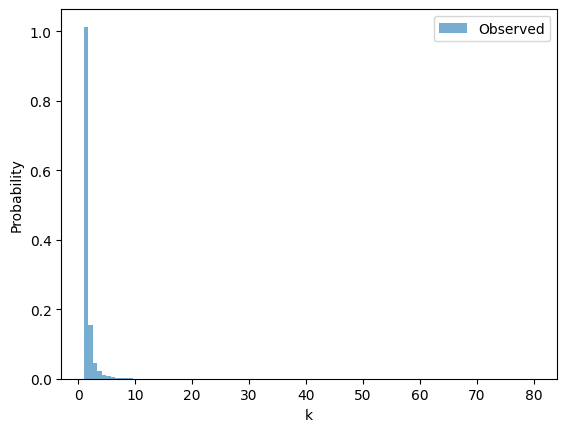

run:  0.7039313088865782


In [81]:
# plot: 


# Histogram of observed data
np.random.seed(42)
X = pareto_composition(k,1,10000)
plt.hist(X,
        bins=100,
        density=True,
        alpha=0.6,
        label='Observed')

# Theoretical

#x = np.linspace(beta,np.max(X),100000)
#theoretical_pdf_pareto = k[i]*beta**k[i]/(x**(k[i]+1))


#plt.plot(x, theoretical_pdf_pareto, '-', label='Theoretical')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()


stat, p_value = runstest_1samp(X,cutoff='median')
print("run: ", p_value)

# Exercise 4

## 1

In [103]:
def discrete_system(m, ms, ma, n):

    blocked_customers = 0
    process = np.zeros(m)

    t = 0.0

    for _ in range(n):

        # arrival
        t += np.random.exponential(ma)

        # Set process free after their time
        process[process <= t] = 0

        # Find free process
        idle_process = np.where(process == 0)[0]

        if len(idle_process) > 0:
            process_id = idle_process[0]
            service_time = np.random.exponential(ms)
            process[process_id] = t + service_time

        else:
            blocked_customers += 1

    return blocked_customers / n

In [104]:
blocked = []
for _ in range(10):
    blocked.append(discrete_system(10,8,1,10000))
blocked

[0.1234, 0.118, 0.1244, 0.1245, 0.1145, 0.1226, 0.1203, 0.1169, 0.1201, 0.1213]

In [105]:
# Confidence interval
mean = np.mean(blocked)
sd = np.std(blocked)

CI_lower = mean-t.ppf(0.975, df=n-1)*sd/np.sqrt(n)
CI_upper = mean+t.ppf(0.975, df=n-1)*sd/np.sqrt(n)

CI_lower,CI_upper

(0.11833806906417411, 0.12286193093582591)

In [106]:
import math as math
A = 8*1
m = 10
denom = []
for i in range(m+1):
    denom.append(A**(i)/(math.factorial(i)))
Theory = (A**m/math.factorial(m))/(sum(denom))
Theory

0.12166106425295149

## 2

In [ ]:

def discrete_system_erlang(m, ms, k,rate, n):

    blocked_customers = 0
    process = np.zeros(m)
    erlang_rate = 1/(rate*k)

    t = 0.0

    for _ in range(n):

        # arrival
        t += np.random.gamma(shape=k, scale=erlang_rate)

        # Set process free after their time
        process[process <= t] = 0

        # Find free process
        idle_process = np.where(process == 0)[0]

        if len(idle_process) > 0:
            process_id = idle_process[0]
            service_time = np.random.exponential(ms)
            process[process_id] = t + service_time

        else:
            blocked_customers += 1

    return blocked_customers / n


0.0

In [108]:
blocked = []
for _ in range(10):
    blocked.append(discrete_system_erlang(10,8,2,1,10000))
blocked

[0.089, 0.0999, 0.1008, 0.0967, 0.1014, 0.0908, 0.0916, 0.0857, 0.0967, 0.0887]

In [109]:
mean = np.mean(blocked)
sd = np.std(blocked)

CI_lower = mean-t.ppf(0.975, df=n-1)*sd/np.sqrt(n)
CI_upper = mean+t.ppf(0.975, df=n-1)*sd/np.sqrt(n)

CI_lower,CI_upper

(0.09028965257191081, 0.0979703474280892)

In [148]:
def hyper_exp(lamba, p):
    i = np.random.choice(len(p),p=p)
    return np.random.exponential(1/lamba[i])

def discrete_system_hyper(m, ms,lamba,p , n):

    blocked_customers = 0
    process = np.zeros(m)
    t = 0.0

    for _ in range(n):

        # arrival
        t += hyper_exp(lamba,p)

        # Set process free after their time
        process[process <= t] = 0

        # Find free process
        idle_process = np.where(process == 0)[0]

        if len(idle_process) > 0:
            process_id = idle_process[0]
            service_time = np.random.exponential(ms)
            process[process_id] = t + service_time

        else:
            blocked_customers += 1

    return blocked_customers / n

In [150]:
blocked = []
lamba = [0.8333,5]
p = [0.8,0.2]
for _ in range(10):
    blocked.append(discrete_system_hyper(10,8,lamba,p,10000))
blocked

[0.134, 0.1371, 0.1424, 0.1425, 0.1352, 0.1488, 0.1384, 0.1333, 0.1288, 0.1419]

In [151]:
mean = np.mean(blocked)
sd = np.std(blocked)

CI_lower = mean-t.ppf(0.975, df=n-1)*sd/np.sqrt(n)
CI_upper = mean+t.ppf(0.975, df=n-1)*sd/np.sqrt(n)

CI_lower,CI_upper

(0.13430603129470117, 0.14217396870529878)

## 3

In [152]:
def discrete_system_constant(m, c, ma, n):

    blocked_customers = 0
    process = np.zeros(m)

    t = 0.0

    for _ in range(n):

        # arrival
        t += np.random.exponential(ma)

        # Set process free after their time
        process[process <= t] = 0

        # Find free process
        idle_process = np.where(process == 0)[0]

        if len(idle_process) > 0:
            process_id = idle_process[0]
            service_time = c
            process[process_id] = t + service_time

        else:
            blocked_customers += 1

    return blocked_customers / n

In [153]:
for _ in range(10):
    blocked.append(discrete_system_constant(10,8,1,10000))
blocked

[0.134,
 0.1371,
 0.1424,
 0.1425,
 0.1352,
 0.1488,
 0.1384,
 0.1333,
 0.1288,
 0.1419,
 0.1194,
 0.1183,
 0.1199,
 0.1211,
 0.1223,
 0.1168,
 0.1272,
 0.1216,
 0.1258,
 0.1197]

In [154]:
mean = np.mean(blocked)
sd = np.std(blocked)

CI_lower = mean-t.ppf(0.975, df=n-1)*sd/np.sqrt(n)
CI_upper = mean+t.ppf(0.975, df=n-1)*sd/np.sqrt(n)

CI_lower,CI_upper

(0.12285232696177041, 0.1365976730382296)

In [155]:
def pareto_distrib(k, beta, n):
    U = np.random.rand(n)
    return beta*(U**(-1/k))

def discrete_system_pareto(m, k,beta, ma, n):

    blocked_customers = 0
    process = np.zeros(m)

    t = 0.0

    for _ in range(n):

        # arrival
        t += np.random.exponential(ma)

        # Set process free after their time
        process[process <= t] = 0

        # Find free process
        idle_process = np.where(process == 0)[0]

        if len(idle_process) > 0:
            process_id = idle_process[0]
            service_time = pareto_distrib(k,beta,1)
            process[process_id] = t + service_time

        else:
            blocked_customers += 1

    return blocked_customers / n

In [160]:
k = 1.05
beta = (k-1)/k*8
for _ in range(10):
    blocked.append(discrete_system_pareto(10,k,beta,1,10000))

mean = np.mean(blocked)
sd = np.std(blocked)

CI_lower = mean-t.ppf(0.975, df=n-1)*sd/np.sqrt(n)
CI_upper = mean+t.ppf(0.975, df=n-1)*sd/np.sqrt(n)

CI_lower,CI_upper

C:\Users\Bruger\AppData\Local\Temp\ipykernel_26444\2997188597.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  process[process_id] = t + service_time


(0.010229080188066515, 0.09966520552621919)

In [158]:
k = 2.05
beta = (k-1)/k*8
for _ in range(10):
    blocked.append(discrete_system_pareto(10,8,k,beta,10000))

mean = np.mean(blocked)
sd = np.std(blocked)

CI_lower = mean-t.ppf(0.975, df=n-1)*sd/np.sqrt(n)
CI_upper = mean+t.ppf(0.975, df=n-1)*sd/np.sqrt(n)

CI_lower,CI_upper

C:\Users\Bruger\AppData\Local\Temp\ipykernel_26444\2997188597.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  process[process_id] = t + service_time


(0.031828361223819004, 0.12082763877618098)